### Robot Learning

### Assignment 2

Solutions are due on 29.04.2025 before the lecture.

### Introduction

Consider the following $9 \times 9$ grid world:

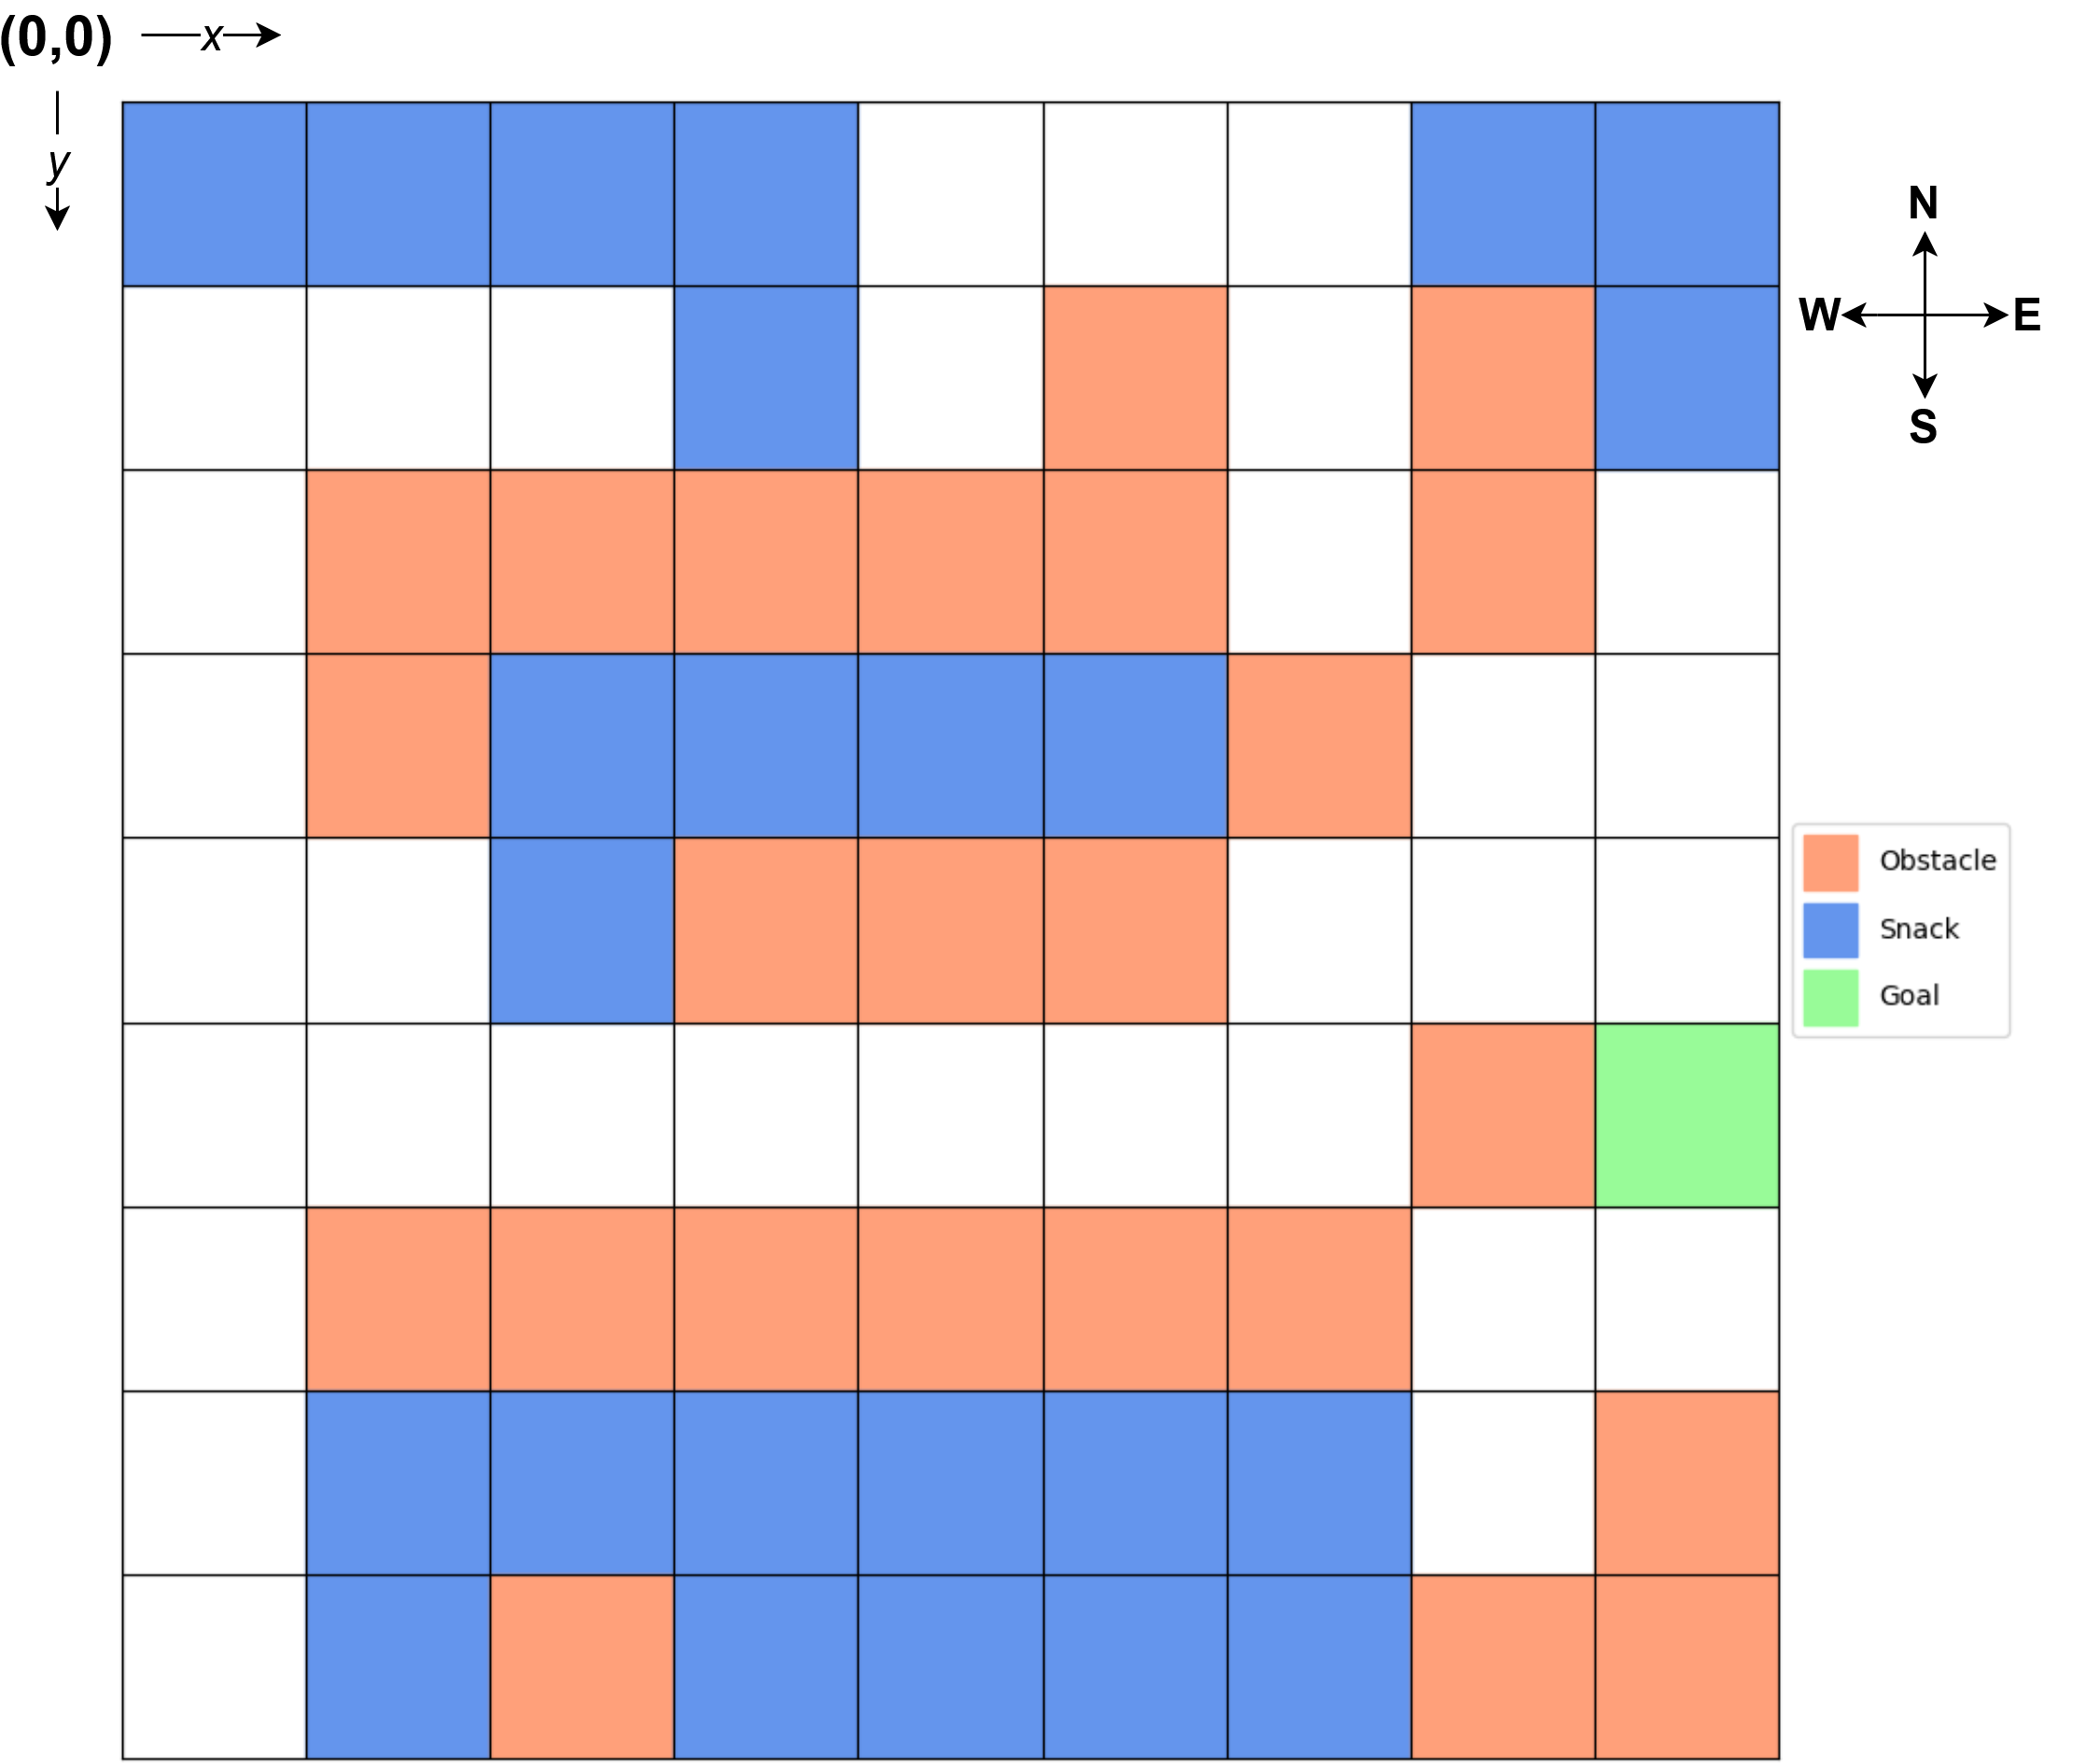

In [1]:
from IPython.display import Image, display
display(Image(filename='helpers/rl_grid_sketch_25.png', width=650))

The agent may start in any cell that is not an obstacle nor the goal.

It can choose between eight actions, which correspond to moving to the directions 

$$a_i \in \{NW,      N,      NE,     E,     SE,    S,     SW,     W\}$$

These are indexed according to the order above, i.e. $a_0 = NW$ and $a_6 = SW$.

The agent must be careful, for the actions are non-deterministic! The agent moves with probability $0.8$ into the desired
direction, but with probability $0.15$ deviates $45^{\circ}$ to the left and with probability $0.05$ deviates $45^{\circ}$ 
to the right of the desired direction due to treacherous gusts unexpectedly sweeping the grid.

The rewards are structured as follows:

* When it reaches a blue cell, it receives a little snack of 16 points.

* When it attempts to enter a red obstacle cell, it receives -32 points and stays in the cell it came from.

* When it attempts to leave the grid, it receives -32 points and stays in the cell it came from.

* When the agent reaches the green goal cell, it receives 180 points and the episode ends.

* All other actions entering a white cell receive -1 point.

## Task 2.1

To familiarize yourself with the environment above, answer the following questions:

* The agent is at $s = (y_s, x_s) = (3, 5)$ and wants to execute $a_5$. What is the probability $P^a_{s,s'}$ for $s' =(4,6)$?


* The agent is at $s = (4, 7)$ and wants to execute $a_3$. What is the expected value of the reward?

<div style="text-align: right; font-weight:bold"> 1 + 2 = 3 Points </div>

<!--### $s= (3,5)$ color Blue , $a5= South$,  $P^a_{s,s'}$=?

as per question it has to move in south directtion, but the cell which is absolute south is red which means no movement is possible in s direction!

in description of this problem it was mentioned the probability of deviating is given for both left and right directions 

so the agent may end three respective positions when the movement is in s-direction namely 1
* (4,5) absolute s with 0.8 probability & color red, 
* (4,4) deviated to right with 0.05 probability & color red due to wind
* (4,6) deviated to right with 0.15 probability & color white due to wind -->
### The agent may end in cell(4,6) with $P^a5_{4,6}$ = 0.15

<!-- ## $s = (4, 7)$  $a_3 = East$ Expected reward=?
 W= white(-1) , G is Goal(180) , R is Red(-32)
cells that agent might end up in : (3,8)W , (4,8)W ,(5,8)G -->

E = reward* prob actual direction + reward * (left deviation prob) + reward * (right deviation prob) 

###  Expected reward = 8.05

## Task 2.2)

Using the *Iterative Policy Evaluation* Algorithm, compute the value $V^{\pi}(s)$ of all accessible cells $s$ for a policy $\pi(s,a)$ that chooses with probability $0.5$ a random action and otherwise attempts to move to the right.

Intialize $V(s)$ with zero, use a discount parameter of $\gamma=0.9$ and show your results by printing your state values $V^{\pi}(s)$.

<div style="text-align: right; font-weight:bold"> 5 Points </div>

#### Note

For your convenience, you are provided the helper function *getNextStatesRewardsAndProbabilities(state, action)* which returns for a given state $s$ and an action $a$ a list of 3 -tuples of the form

$$[(s_0', R^a_{s,s_0'}, P^a_{s,s_0'}), (s_1', R^a_{s,s_1'}, P^a_{s,s_1'}), \dots]$$

where $s_i'$ are all future states with $P^a_{s,s_i'} \neq 0$. Here $s = (y, x)$ and $s_i' = (y_i', x_i')$ are both tuples of integers, $a \in {0, \dots, 7}$ is an integer, and $R^a_{s,s_i'}$, $P^a_{s,s_i'}$ are both floats.

Also, please find below some data structures which you might find helpful. Create code and text cells as necessary to present your solution!

In your implementation, $V(s)$ should be a $9 \times 9$ numpy array and $\pi(s,a)$ should be a $9 \times 9 \times 8$ numpy array, where $\sum_a \pi(s,a) = 1$ for all s!

In [2]:
import numpy as np
from helpers.utils import getNextStatesRewardsAndProbabilities
%matplotlib inline

#this is a list of all states
states = [(y,x) for y in range(9) for x in range(9)]
#this is a list of all states containing obstacles
obstacles = [(1,5), (1,7), \
             (2,1), (2,2), (2,3), (2,4), (2,5), (2,7),\
             (3,1), (3,6), \
             (4,3), (4,4), (4,5), \
             (5,7), \
             (6,1), (6,2), (6,3), (6,4), (6,5), (6,6), \
             (7,8), \
             (8,2), (8,7), (8,8)]
#this is a list containing all blue cells
snacks = [(0,0), (0,1), (0,2), (0,3), (0,7), (0,8), \
          (1,3), (1,8), \
          (3,2), (3,3), (3,4), (3,5), \
          (4,2), \
          (7,1), (7,2), (7,3), (7,4), (7,5), (7,6), \
          (8,1), (8,3), (8,4), (8,5), (8,6)]
#this is a list containing all goal states
terminalStates = [(5,8)]
#this is an array containing all actions
actions = np.array([0, 1, 2, 3, 4, 5, 6, 7]) #[NW,      N,      NE,     E,     SE,    S,     SW,     W]
#example of how to unpack getNextStatesRewardsAndProbabilities(state, action):
#create dummy state and action
s_test = (0,6)
a_test = 3
#call helper function and loop over the return values
for sPrime, R, P in getNextStatesRewardsAndProbabilities(state=s_test, action=a_test):
    print('sPrime:', sPrime, 'R:', R, 'P:', P)
    
#once you have state values V, you can print them with okay'ish formatting like so:
# print("State Values:")
# print(np.around(V, 1))

sPrime: (0, 6) R: -32.0 P: 0.15
sPrime: (0, 7) R: 16.0 P: 0.8
sPrime: (0, 6) R: -32.0 P: 0.05


In [3]:
# Your code goes here
V = np.zeros((9,9))
gamma = 0.9
# phi = 0.5 correct , pi  = 0.5/8 random ; phi + pi = 1
pi = (0.5/8) * np.ones((9,9,8))
pi[:, :, 3] += 0.5
delta = 0.0001
while True:
    delta = 0
    for y in range(9):
        for x in range(9):
            s = (y, x)
            if s in obstacles or s in terminalStates:
                continue
            v = 0

            for actions in range(8):
                p_action = pi[y, x, actions]
                policy = getNextStatesRewardsAndProbabilities(s, actions)

                for next_state, reward, prob in policy:
                    v += p_action * prob * (reward + gamma * V[next_state])
            delta = max(delta, abs(v - V[s]))
            V[s] = v
    if delta < 0.01:
        break
print("State Values:")
print(np.around(V, 1))


State Values:
[[ -82.3  -86.8 -103.6 -129.7 -145.1 -158.3 -166.6 -191.1 -231.4]
 [ -90.5  -92.1 -102.7 -134.1 -159.     0.  -184.3    0.  -221.1]
 [-147.1    0.     0.     0.     0.     0.  -192.8    0.  -206.2]
 [-162.5    0.  -111.  -126.6 -150.9 -174.1    0.  -147.7 -169.7]
 [-105.7  -97.7 -119.9    0.     0.     0.  -102.8  -85.8 -109.6]
 [-102.1 -103.8 -116.2 -121.8 -121.5 -112.9 -114.4    0.     0. ]
 [-108.3    0.     0.     0.     0.     0.     0.   -45.2  -88.9]
 [ -53.   -46.9  -39.5  -42.7  -52.5  -70.7  -90.2 -114.8    0. ]
 [ -64.2  -83.2    0.   -41.1  -54.3  -79.9 -118.5    0.     0. ]]


## Task 2.3)

Now it is time to find a good policy. Use the *Policy Iteration* algorithm to compute the optimal value $V^*(s)$ for each accessible cell.

Retrieve the resulting optimal-policy $\pi^*(s)$. To obtain a greedy policy given $V(s)$, make use of:

$$\pi_{greedy}(s) := \operatorname{argmax}_a Q(s,a) = \operatorname{argmax}_a \sum_{s'}P_{ss'}^a\cdot[R_{ss'}^a+\gamma\cdot V(s')]$$

As implied by these terms, we recommend using intermediate state-action $Q$-values, shaped $9 \times 9 \times 8$ for this step!

Finally, present your results by printing $V^*(s)$ and using our helper function *drawPolicy()* to visualize $\pi^*(s,a)$.

<div style="text-align: right; font-weight:bold"> 5 Points </div>

In [4]:
from helpers.utils import drawPolicy, drawGrid
#show policy using helper function as below
#usage of the helper function, where pi is a (9,9,8) numpy array representing a deterministic policy:
#drawPolicy(pi)
#deterministic here means that one action per state has probability 1 and all others have probability 0
#this will plot arrows representing your policies into the grid world.

optimal  State Values: V* 
[[  7.95  16.77  23.13  27.7   33.55  21.6    8.35  13.6   16.19]
 [ 28.3   34.07  39.07  39.73  41.97   0.    21.97   0.    27.09]
 [ 25.8    0.     0.     0.     0.     0.     8.62   0.    25.91]
 [ 11.37   0.     7.95  19.32  20.31  21.03   0.    13.    11.45]
 [  0.99  16.22  28.59   0.     0.     0.    21.54 142.25 137.6 ]
 [ 10.81  35.37  33.82  36.2   18.86   9.86 102.78   0.     0.  ]
 [ 24.38   0.     0.     0.     0.     0.     0.   139.15 137.6 ]
 [ 15.15  17.05  25.87  25.03  31.62  36.37  94.54 115.31   0.  ]
 [ 27.77  34.53   0.    42.15  46.45  88.98  95.78   0.     0.  ]]
optimal  Policy: pi* 


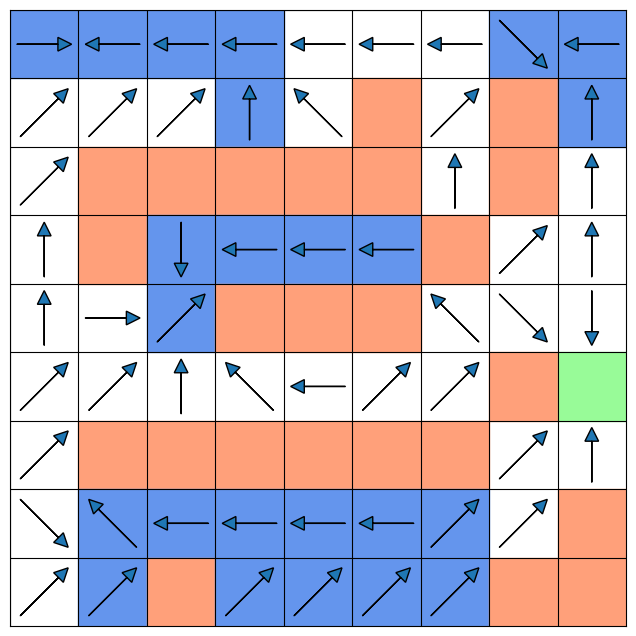

In [5]:
# Your code goes here
from helpers.utils import drawPolicy, drawGrid

V = np.zeros((9, 9))
gamma = 0.9
delta  = 0.0001
pi = np.zeros((9,9,8), dtype=int)
#Q = np.zeros((9,9,8))


for y in range(9):
    for x in range(9):
        s = (y, x)
        if s in obstacles or s in terminalStates:
            continue
        old_v = V[s]
        Q = np.zeros(8)
        for actions in range(8):
            policy = getNextStatesRewardsAndProbabilities(s, actions)
            for next_state, reward, prob in policy:
                ny, nx = next_state
                Q[actions] += prob * (reward + gamma * V[ny, nx])

                
        best_action = np.argmax(Q)
        V[s] = Q[best_action]
        pi[y, x, best_action] = 1.

np.set_printoptions(precision=2)
print("optimal  State Values: V* ")
print(V)
print("optimal  Policy: pi* ")
drawPolicy(pi)

## Task 2.4)

Verify your results from the previous task by using the *Value Iteration* algorithm to compute the optimal value $V^*(s)$ for each cell. Make sure to reinitialize $V(s)$ with zero.

Finally, present your results by printing $V^*(s)$ and using our helper function *drawPolicy()* to visualize $\pi^*(s,a)$.

<div style="text-align: right; font-weight:bold"> 4 Points </div>

In [6]:
# Your code goes here

Optimal State Values V* (from Value Iteration):
[[129.27 135.36 142.62 140.25 140.97 123.63 106.97 112.94 106.97]
 [136.47 142.56 143.27 141.79 141.62   0.   111.84   0.   110.85]
 [124.1    0.     0.     0.     0.     0.   125.29   0.   134.05]
 [100.21   0.   114.5  117.38 115.04 122.13   0.   152.69 152.85]
 [106.87 121.56 118.92   0.     0.     0.   149.1  172.67 167.8 ]
 [113.01 119.96 118.41 117.97 105.75 130.43 148.59   0.     0.  ]
 [138.71   0.     0.     0.     0.     0.     0.   169.6  167.8 ]
 [152.26 146.09 157.49 160.   160.   160.   160.   157.49   0.  ]
 [150.71 153.63   0.   160.   160.   160.   160.     0.     0.  ]]
Optimal Policy π* (from Value Iteration):


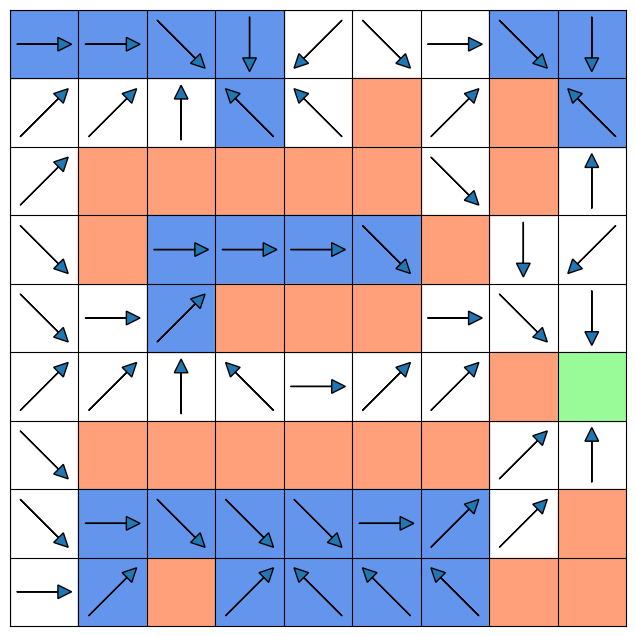

In [7]:
import numpy as np

# Initialize V(s) = 0
V = np.zeros((9, 9))

# Create empty policy array to store best actions
pi = np.zeros((9, 9,8), dtype=int)

gamma = 0.9
theta = 1e-4  # Threshold for convergence
while True:
    delta = 0
    V_new = np.copy(V)

    for y in range(9):
        for x in range(9):
            state = (y, x)

            if state in obstacles or state in terminalStates:
                continue

            Q_values = np.zeros(8)

            for a in range(8):
                transitions = getNextStatesRewardsAndProbabilities(state, a)

                for next_state, reward, prob in transitions:
                    ny, nx = next_state
                    Q_values[a] += prob * (reward + gamma * V[ny, nx])

            # Bellman optimality update: take maximum Q
            V_new[y, x] = np.max(Q_values)

            delta = max(delta, abs(V_new[y, x] - V[y, x]))

    V = V_new

    if delta < theta:
        break

    for y in range(9):
        for x in range(9):
            state = (y, x)

            if state in obstacles or state in terminalStates:
                continue
    
            Q_values = np.zeros(8)
    
            for a in range(8):
                transitions = getNextStatesRewardsAndProbabilities(state, a)
    
                for next_state, reward, prob in transitions:
                    ny, nx = next_state
                    Q_values[a] += prob * (reward + gamma * V[ny, nx])
    
            pi[y, x, np.argmax(Q_values)] = 1.

# Print final optimal V*
np.set_printoptions(precision=2, suppress=True)
print("Optimal State Values V* (from Value Iteration):")
print(V)

# Draw the policy
print("Optimal Policy π* (from Value Iteration):")
drawPolicy(pi)


## Task 2.5)

Modify your implementation of *Value Iteration* or *Policy Iteration* to ignore the random deviations in the environment. This can be achieved by calling *getNextStatesRewardsAndProbabilities(state, action, deviation=False)*.

Present your results by printing $V^*(s)$ and using our helper function *drawPolicy()* to visualize $\pi^*(s,a)$. How and why have your state values and policy changed?

<div style="text-align: right; font-weight:bold"> 3 Points </div>

In [8]:
# Your code goes here

Optimal V* (Deterministic case):
[[160.   160.   160.   160.   160.   143.   160.   160.   160.  ]
 [160.   160.   160.   160.   160.     0.   160.     0.   160.  ]
 [143.     0.     0.     0.     0.     0.   160.     0.   160.  ]
 [143.     0.   160.   160.   160.   160.     0.   161.   161.  ]
 [143.   160.   160.     0.     0.     0.   161.   180.   180.  ]
 [143.48 160.   160.   160.   143.   143.9  161.     0.     0.  ]
 [160.53   0.     0.     0.     0.     0.     0.   180.   180.  ]
 [160.53 160.59 160.66 160.73 160.81 160.9  161.   161.     0.  ]
 [160.53 160.59   0.   160.73 160.81 160.9  160.9    0.     0.  ]]
Optimal Policy π* (Deterministic case):


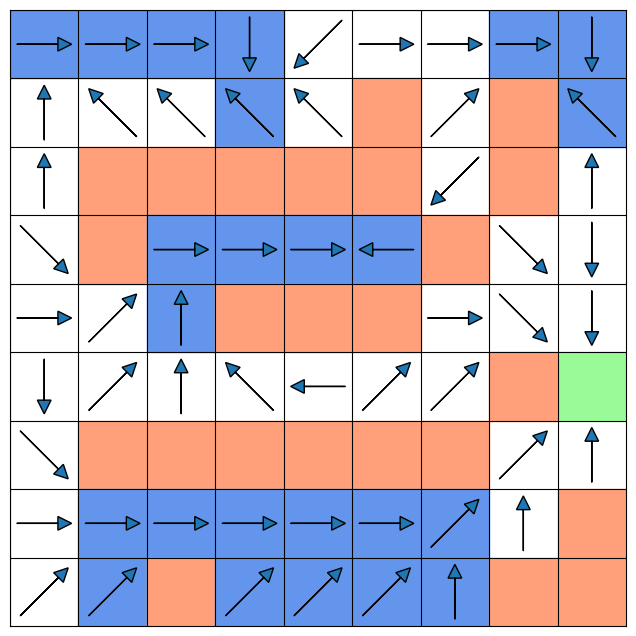

In [9]:
V = np.zeros((9, 9))
pi = np.zeros((9, 9,8), dtype=int)

gamma = 0.9
theta = 1e-4
while True:
    delta = 0
    V_new = np.copy(V)

    for y in range(9):
        for x in range(9):
            state = (y, x)

            if state in obstacles or state in terminalStates:
                continue

            Q_values = np.zeros(8)

            for a in range(8):
                # Now deviation=False !!
                transitions = getNextStatesRewardsAndProbabilities(state, a, deviation=False)

                for next_state, reward, prob in transitions:
                    ny, nx = next_state
                    Q_values[a] += prob * (reward + gamma * V[ny, nx])

            V_new[y, x] = np.max(Q_values)
            delta = max(delta, abs(V_new[y, x] - V[y, x]))

    V = V_new

    if delta < theta:
        break
for y in range(9):
    for x in range(9):
        state = (y, x)

        if state in obstacles or state in terminalStates:
            continue

        Q_values = np.zeros(8)

        for a in range(8):
            transitions = getNextStatesRewardsAndProbabilities(state, a, deviation=False)

            for next_state, reward, prob in transitions:
                ny, nx = next_state
                Q_values[a] += prob * (reward + gamma * V[ny, nx])

        pi[y, x, np.argmax(Q_values)] = 1.

        np.set_printoptions(precision=2, suppress=True)
print("Optimal V* (Deterministic case):")
print(V)

print("Optimal Policy π* (Deterministic case):")
drawPolicy(pi)



Please answer in this text cell.